In [1]:
import pandas as pd
import mysql.connector

In [2]:
import matplotlib.pyplot as plt

In [3]:
patients = pd.read_csv("/Users/maheshbabu/Desktop/project/data/patients_1000.csv")
doctors = pd.read_csv("/Users/maheshbabu/Desktop/project/data/doctors_1000.csv")
medicines = pd.read_csv("/Users/maheshbabu/Desktop/project/data/medicines_1000.csv")
prescriptions = pd.read_csv("/Users/maheshbabu/Desktop/project/data/prescriptions_1000.csv")

In [4]:
doctors.head()

,doctor_id,doctor_name,specialization,hospital_name
0,D0001,Doctor_1,Cardiology,Fortis
1,D0002,Doctor_2,Pediatrics,Apollo
2,D0003,Doctor_3,Pediatrics,Max
3,D0004,Doctor_4,Cardiology,Fortis
4,D0005,Doctor_5,Pediatrics,Max


In [5]:
patients.head()

,patient_id,patient_name,gender,age,contact_no
0,P0001,Patient_1,F,NaN,NaN
1,P0002,Patient_2,M,47.0,9.236837e+09
2,P0003,Patient_3,F,74.0,9.918519e+09
3,P0004,Patient_4,F,60.0,9.875935e+09
4,P0005,Patient_5,M,NaN,NaN


In [6]:
medicines.head()

,medicine_id,medicine_name,category
0,M0001,Medicine_1,Cardiac
1,M0002,Medicine_2,Antibiotic
2,M0003,Medicine_3,Diabetes
3,M0004,Medicine_4,Antibiotic
4,M0005,Medicine_5,Respiratory


In [7]:
prescriptions.head()

,prescription_id,patient_id,doctor_id,medicine_id,dosage,frequency,prescribed_date
0,PR0001,P0144,D0372,M0815,NaN,Twice a day,2024-03-03
1,PR0002,P0820,D0882,M0935,250mg,NaN,2024-01-24
2,PR0003,P0932,D0974,M0285,NaN,NaN,2024-07-12
3,PR0004,P0072,D0024,M0352,NaN,NaN,2024-10-19
4,PR0005,P0497,D0488,M0394,500mg,NaN,2024-12-13


Transform: Data Cleaning & Enrichment

In [8]:
# Remove duplicates
doctors = doctors.drop_duplicates()
patients = patients.drop_duplicates()
medicines = medicines.drop_duplicates()
prescriptions = prescriptions.drop_duplicates()

In [10]:
# patients table
# Handle missing values
patients = patients.ffill()

patients["patient_name"] = patients["patient_name"].fillna("Unknown Patient")
patients["gender"] = patients["gender"].fillna("Not Specified")
patients["contact_no"] = patients["contact_no"].fillna("Not Available")

In [11]:
# Fill numeric column (age)
patients["age"] = pd.to_numeric(patients["age"], errors="coerce")
patients["age"] = patients["age"].fillna(patients["age"].median())

In [12]:
# prescriptions table
# Convert date safely
prescriptions["prescribed_date"] = pd.to_datetime(
    prescriptions["prescribed_date"], errors="coerce"
)

In [13]:
# Fill dosage and frequency
prescriptions["dosage"] = prescriptions["dosage"].fillna("400mg")
prescriptions["frequency"] = prescriptions["frequency"].fillna("Once a day")

In [14]:
# Fill missing date with today's date (optional)
prescriptions["prescribed_date"] = prescriptions["prescribed_date"].fillna(pd.Timestamp.today())
print("Data Cleaning Completed ✅")

Data Cleaning Completed ✅


Connecting to MySQL and Creating Database (Load)

In [15]:
from sqlalchemy import create_engine, text
from urllib.parse import quote_plus

In [16]:
# MySQL Login Details
username = "root"
password = quote_plus("Mahesh@99")   # your password
host = "localhost"
port = 3306
db_name = "digital_prescription_database"

In [17]:
# 1) Connect to MySQL (without DB)
engine = create_engine(
    f"mysql+mysqlconnector://{username}:{password}@{host}:{port}"
)

print("MySQL Connected Successfully ✅")

MySQL Connected Successfully ✅


In [18]:
# 2) Create Database
with engine.connect() as conn:
    conn.execute(text(f"CREATE DATABASE IF NOT EXISTS {db_name}"))
    print(f"Database '{db_name}' Created/Exists ✅")

Database 'digital_prescription_database' Created/Exists ✅


In [20]:
# 3) Connect to Database
engine_db = create_engine(
    f"mysql+mysqlconnector://{username}:{password}@{host}:{port}/{db_name}"
)
print(f"Connected to Database '{db_name}' ✅")

Connected to Database 'digital_prescription_database' ✅


Load: Creating tables

In [21]:
# 4) Create Tables + Indexes
create_tables_sql = """
-- Patients table
CREATE TABLE IF NOT EXISTS patients (
    patient_id VARCHAR(10) PRIMARY KEY,
    patient_name VARCHAR(100) NOT NULL,
    gender CHAR(1) DEFAULT 'U',
    age INT,
    contact_no VARCHAR(15),
    created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP,
    CHECK (gender IN ('M','F','U')),
    CHECK (age BETWEEN 0 AND 100)
);

-- Doctors table
CREATE TABLE IF NOT EXISTS doctors (
    doctor_id VARCHAR(10) PRIMARY KEY,
    doctor_name VARCHAR(100) NOT NULL,
    specialization VARCHAR(100),
    hospital_name VARCHAR(100),
    created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
);

-- Medicines table
CREATE TABLE IF NOT EXISTS medicines (
    medicine_id VARCHAR(10) PRIMARY KEY,
    medicine_name VARCHAR(100) NOT NULL,
    category VARCHAR(50),
    created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
);

-- Prescriptions table
CREATE TABLE IF NOT EXISTS prescriptions (
    prescription_id VARCHAR(10) PRIMARY KEY,
    patient_id VARCHAR(10) NOT NULL,
    doctor_id VARCHAR(10) NOT NULL,
    medicine_id VARCHAR(10) NOT NULL,
    dosage VARCHAR(50) DEFAULT 'Not Provided',
    frequency VARCHAR(50) DEFAULT 'Not Provided',
    prescribed_date DATE NOT NULL,
    created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP,

    CONSTRAINT fk_patient FOREIGN KEY (patient_id)
        REFERENCES patients(patient_id)
        ON DELETE RESTRICT
        ON UPDATE CASCADE,

    CONSTRAINT fk_doctor FOREIGN KEY (doctor_id)
        REFERENCES doctors(doctor_id)
        ON DELETE RESTRICT
        ON UPDATE CASCADE,

    CONSTRAINT fk_medicine FOREIGN KEY (medicine_id)
        REFERENCES medicines(medicine_id)
        ON DELETE RESTRICT
        ON UPDATE CASCADE
);

-- Optional staging table
CREATE TABLE IF NOT EXISTS staging_prescriptions (
    prescription_id VARCHAR(10),
    patient_id VARCHAR(10),
    doctor_id VARCHAR(10),
    medicine_id VARCHAR(10),
    dosage VARCHAR(50),
    frequency VARCHAR(50),
    prescribed_date VARCHAR(20)
);

-- Indexes
CREATE INDEX idx_prescribed_date ON prescriptions(prescribed_date);
CREATE INDEX idx_doctor_id ON prescriptions(doctor_id);
CREATE INDEX idx_medicine_id ON prescriptions(medicine_id);
"""

In [22]:
# Execute each statement safely
with engine_db.connect() as conn:
    for stmt in create_tables_sql.split(";"):
        stmt = stmt.strip()
        if stmt:
            conn.execute(text(stmt))
    conn.commit()


In [23]:
# 5) Show Created Tables
with engine_db.connect() as conn:
    result = conn.execute(text("SHOW TABLES"))
    tables = result.fetchall()
    print("\nTables in Database:")
    for t in tables:
        print(" -", t[0])


Tables in Database:
 - doctors
 - medicines
 - patients
 - prescriptions
 - staging_prescriptions


In [24]:
from sqlalchemy import text
patients.to_sql("patients", con=engine_db, if_exists="append", index=False)
doctors.to_sql("doctors", con=engine_db, if_exists="append", index=False)
medicines.to_sql("medicines", con=engine_db, if_exists="append", index=False)
prescriptions.to_sql("prescriptions", con=engine_db, if_exists="append", index=False)

print("All cleaned data inserted into MySQL ✅")

All cleaned data inserted into MySQL ✅


SQL Analytical Queries for Business Problems

(1) Most Prescribed Medicines

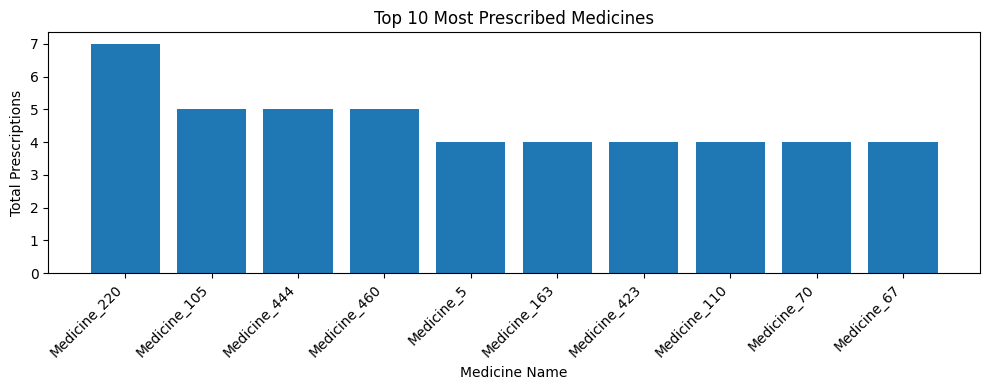

In [26]:
query = """
SELECT m.medicine_name, COUNT(*) AS total_prescriptions
FROM prescriptions p
JOIN medicines m ON p.medicine_id = m.medicine_id
GROUP BY m.medicine_name
ORDER BY total_prescriptions DESC
LIMIT 10;
"""

df = pd.read_sql(query, engine_db)

plt.figure(figsize=(10,4))
plt.bar(df["medicine_name"], df["total_prescriptions"])
plt.xticks(rotation=45, ha="right")
plt.title("Top 10 Most Prescribed Medicines")
plt.xlabel("Medicine Name")
plt.ylabel("Total Prescriptions")
plt.tight_layout()
plt.show()

(2) Doctors by Prescription Volume

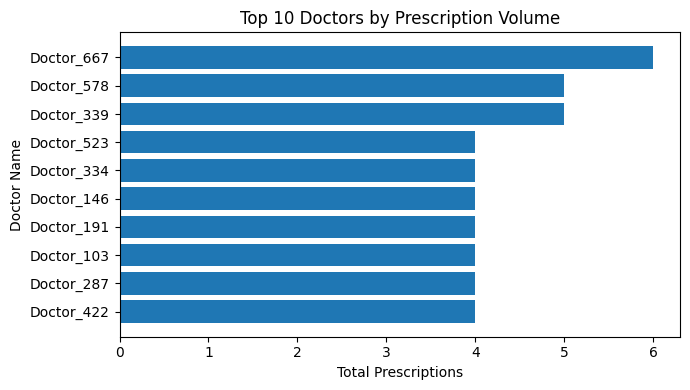

In [27]:
query = """
SELECT d.doctor_name, COUNT(*) AS total_prescriptions
FROM prescriptions p
JOIN doctors d ON p.doctor_id = d.doctor_id
GROUP BY d.doctor_name
ORDER BY total_prescriptions DESC
LIMIT 10;
"""

df = pd.read_sql(query, engine_db)

# Reverse so highest comes on top
df = df.iloc[::-1]

plt.figure(figsize=(7,4))
plt.barh(df["doctor_name"], df["total_prescriptions"])

plt.title("Top 10 Doctors by Prescription Volume")
plt.xlabel("Total Prescriptions")
plt.ylabel("Doctor Name")

plt.tight_layout()
plt.show()

(3) Age group vs number of prescriptions

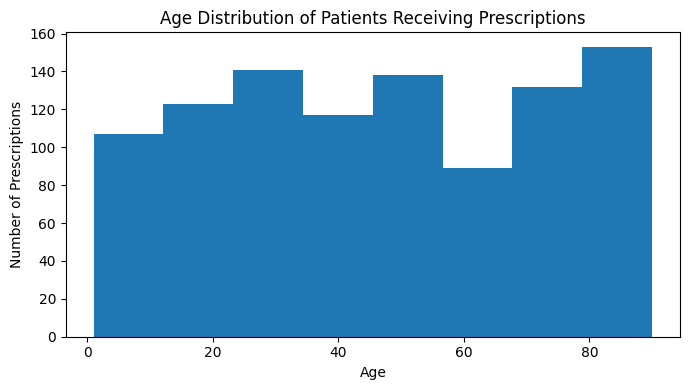

In [29]:
query = """
SELECT pt.age
FROM prescriptions p
JOIN patients pt ON p.patient_id = pt.patient_id;
"""
df = pd.read_sql(query, engine_db)

plt.figure(figsize=(7,4))
plt.hist(df["age"], bins=8)
plt.title("Age Distribution of Patients Receiving Prescriptions")
plt.xlabel("Age")
plt.ylabel("Number of Prescriptions")
plt.tight_layout()
plt.show()

(4) Gender-wise prescription distribution

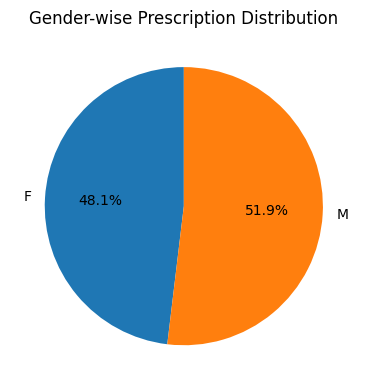

In [28]:
query = """
SELECT pt.gender, COUNT(*) AS total_prescriptions
FROM prescriptions p
JOIN patients pt ON p.patient_id = pt.patient_id
GROUP BY pt.gender;
"""
df = pd.read_sql(query, engine_db)

plt.figure(figsize=(4,4))
plt.pie(df["total_prescriptions"], labels=df["gender"], autopct="%1.1f%%", startangle=90)
plt.title("Gender-wise Prescription Distribution")
plt.tight_layout()
plt.show()

(5) Doctor Prescription Count (Outlier Detection)

In [30]:
query = """
SELECT d.doctor_name, COUNT(*) AS total_prescriptions
FROM prescriptions p
JOIN doctors d ON p.doctor_id = d.doctor_id
GROUP BY d.doctor_name
ORDER BY total_prescriptions DESC;
"""

df = pd.read_sql(query, engine_db)


In [31]:
# IQR Method
Q1 = df["total_prescriptions"].quantile(0.25)
Q3 = df["total_prescriptions"].quantile(0.75)
IQR = Q3 - Q1
upper_limit = Q3 + 1.5 * IQR

In [32]:
# Outlier doctors
outliers = df[df["total_prescriptions"] > upper_limit].copy()

print("Outlier Limit =", upper_limit)

Outlier Limit = 3.5


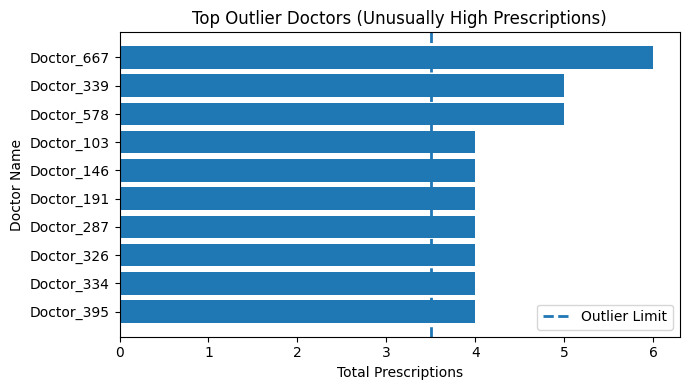

In [33]:
# Top 10 outliers
outliers_top10 = outliers.head(10)

# Plot
if len(outliers_top10) > 0:
    outliers_top10 = outliers_top10.iloc[::-1]   # reverse for better view

    plt.figure(figsize=(7,4))
    plt.barh(outliers_top10["doctor_name"], outliers_top10["total_prescriptions"])

    # Correct limit line for horizontal bar
    plt.axvline(upper_limit, linestyle="--", linewidth=2, label="Outlier Limit")

    plt.title("Top Outlier Doctors (Unusually High Prescriptions)")
    plt.xlabel("Total Prescriptions")
    plt.ylabel("Doctor Name")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("\nNo outlier doctors found.")

(6)  Daily prescription trend over time

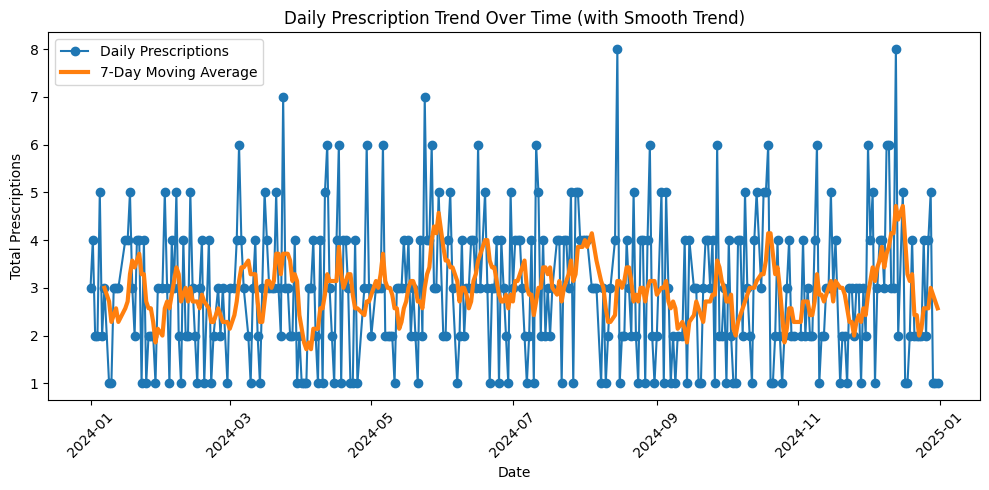

In [34]:
query = """
SELECT prescribed_date, COUNT(*) AS total_prescriptions
FROM prescriptions
GROUP BY prescribed_date
ORDER BY prescribed_date;
"""

df = pd.read_sql(query, engine_db)
df["prescribed_date"] = pd.to_datetime(df["prescribed_date"])

# 7-day moving average (smooth)
df["rolling_7"] = df["total_prescriptions"].rolling(7).mean()

plt.figure(figsize=(10,5))

# Original line
plt.plot(df["prescribed_date"], df["total_prescriptions"], marker="o", label="Daily Prescriptions")

# Smooth trend line
plt.plot(df["prescribed_date"], df["rolling_7"], linewidth=3, label="7-Day Moving Average")

plt.title("Daily Prescription Trend Over Time (with Smooth Trend)")
plt.xlabel("Date")
plt.ylabel("Total Prescriptions")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
(7) Missing data impact analysis before vs after cleaning.

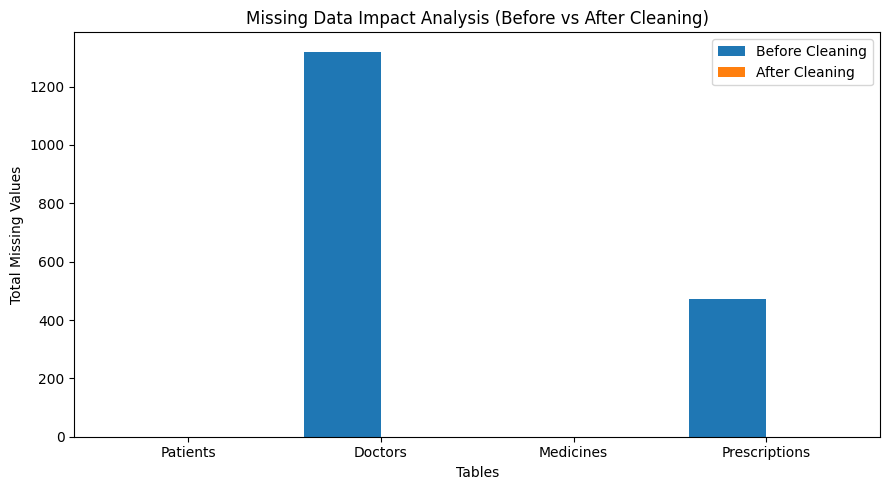

           Table  Missing Before  Missing After
0       Patients               0              0
1        Doctors            1320              0
2      Medicines               0              0
3  Prescriptions             473              0


In [35]:
# ---------------- RAW DATA (Before Cleaning) ----------------
doctors_raw = pd.read_csv("/Users/maheshbabu/Desktop/project/data/patients_1000.csv")
patients_raw = pd.read_csv("/Users/maheshbabu/Desktop/project/data/doctors_1000.csv")
medicines_raw = pd.read_csv("/Users/maheshbabu/Desktop/project/data/medicines_1000.csv")
prescriptions_raw = pd.read_csv("/Users/maheshbabu/Desktop/project/data/prescriptions_1000.csv")

tables = ["Patients", "Doctors", "Medicines", "Prescriptions"]

before_missing = [
    patients_raw.isnull().sum().sum(),
    doctors_raw.isnull().sum().sum(),
    medicines_raw.isnull().sum().sum(),
    prescriptions_raw.isnull().sum().sum()
]

after_missing = [
    patients.isnull().sum().sum(),
    doctors.isnull().sum().sum(),
    medicines.isnull().sum().sum(),
    prescriptions.isnull().sum().sum()
]

# ---------------- Plot Grouped Bar Chart ----------------
x = range(len(tables))

plt.figure(figsize=(9,5))
plt.bar([i - 0.2 for i in x], before_missing, width=0.4, label="Before Cleaning")
plt.bar([i + 0.2 for i in x], after_missing, width=0.4, label="After Cleaning")

plt.xticks(x, tables)
plt.title("Missing Data Impact Analysis (Before vs After Cleaning)")
plt.xlabel("Tables")
plt.ylabel("Total Missing Values")
plt.legend()
plt.tight_layout()
plt.show()

# Print values
df_missing = pd.DataFrame({
    "Table": tables,
    "Missing Before": before_missing,
    "Missing After": after_missing
})

print(df_missing)